In [41]:
import csv
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.stats import chi2_contingency
from pathlib import Path

In [42]:
#Creating a csv file path 
DATA_PATH = (
    Path("Data_Project_1")
    / "NYPD_Arrest_Data__Year_to_Date__20240702.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"CSV file was not found: {DATA_PATH.resolve()}"
    )

nypd_df = pd.read_csv(DATA_PATH)

print(
    f"Loaded {len(nypd_df):,} rows "
    f"and {len(nypd_df.columns)} columns."
)

nypd_df.head(10)

Loaded 63,621 rows and 19 columns.


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,JURISDICTION_CODE,ARREST_PRECINCT,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,New Georeferenced Column
0,280255493,01/10/2024,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 1601001,F,M,0,26,<18,M,BLACK,996342,236149,40.814845,-73.956312,POINT (-73.956312 40.814845)
1,279805419,01/02/2024,157.0,RAPE 1,104.0,RAPE,PL 1303501,F,K,0,77,25-44,M,WHITE HISPANIC,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
2,279895750,01/03/2024,101.0,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,0,106,65+,F,WHITE,1026836,180689,40.662526,-73.846499,POINT (-73.846499 40.662526)
3,280809090,01/19/2024,511.0,"CONTROLLED SUBSTANCE, POSSESSI",235.0,DANGEROUS DRUGS,PL 2200300,M,B,0,49,45-64,M,BLACK,1027430,251104,40.855793,-73.843908,POINT (-73.843908 40.855793)
4,280357135,01/11/2024,109.0,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,F,K,2,81,25-44,F,BLACK,1002457,192292,40.694456,-73.934343,POINT (-73.934343 40.694456)
5,281488967,02/01/2024,157.0,RAPE 1,104.0,RAPE,PL 1303501,F,Q,0,113,25-44,M,BLACK,1046315,187088,40.679981,-73.776234,POINT (-73.7762339071953 40.6799807384666)
6,280769124,01/19/2024,464.0,JOSTLING,230.0,JOSTLING,PL 1652501,M,M,0,6,25-44,M,BLACK,984134,207984,40.737547,-74.000415,POINT (-74.000415 40.737547)
7,281338081,01/30/2024,101.0,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,M,0,26,25-44,M,BLACK,996014,236126,40.814780,-73.957499,POINT (-73.957499 40.81478)
8,280961365,01/23/2024,NaN,(null),NaN,(null),(null),(null),M,97,5,25-44,M,BLACK,983903,200257,40.716337,-74.001251,POINT (-74.001251 40.716337)
9,281426006,01/31/2024,155.0,RAPE 2,104.0,RAPE,PL 1303001,F,B,0,41,18-24,M,BLACK,1013037,236657,40.816206,-73.896001,POINT (-73.8960011932583 40.8162058439227)


In [43]:
nypd_df = pd.read_csv(DATA_PATH)

#Renaming header columns:
#Rename selected columns. 

nypd_df.rename(
    columns={
        "PD_DESC":"OFFENSE",
        "PD_CD":"CLASSIFICATION_CODE",
        "LAW_CAT_CD": "MISDEMEANOR/FELONY",
        "PERP_RACE": "ETHNICITY",
        "OFNS_DESC": "OFFENSE TYPE",
        "PERP_SEX" : "GENDER"
    },
    inplace= True
)

nypd_df.head()



,ARREST_KEY,ARREST_DATE,CLASSIFICATION_CODE,OFFENSE,KY_CD,OFFENSE TYPE,LAW_CODE,MISDEMEANOR/FELONY,ARREST_BORO,JURISDICTION_CODE,ARREST_PRECINCT,AGE_GROUP,GENDER,ETHNICITY,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,New Georeferenced Column
0,280255493,01/10/2024,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 1601001,F,M,0,26,<18,M,BLACK,996342,236149,40.814845,-73.956312,POINT (-73.956312 40.814845)
1,279805419,01/02/2024,157.0,RAPE 1,104.0,RAPE,PL 1303501,F,K,0,77,25-44,M,WHITE HISPANIC,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
2,279895750,01/03/2024,101.0,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,0,106,65+,F,WHITE,1026836,180689,40.662526,-73.846499,POINT (-73.846499 40.662526)
3,280809090,01/19/2024,511.0,"CONTROLLED SUBSTANCE, POSSESSI",235.0,DANGEROUS DRUGS,PL 2200300,M,B,0,49,45-64,M,BLACK,1027430,251104,40.855793,-73.843908,POINT (-73.843908 40.855793)
4,280357135,01/11/2024,109.0,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,F,K,2,81,25-44,F,BLACK,1002457,192292,40.694456,-73.934343,POINT (-73.934343 40.694456)


In [44]:
#Race distribution of arrested individuals 
race_distribution = nypd_df['ETHNICITY'].value_counts()

# Convert the Series to a DataFrame
race_distribution_df = race_distribution.reset_index()

# Rename the columns for clarity
race_distribution_df.columns = (['Race', 'Count'])

race_distribution_df


,Race,Count
0,BLACK,29466
1,WHITE HISPANIC,17191
2,WHITE,6607
3,BLACK HISPANIC,6336
4,ASIAN / PACIFIC ISLANDER,3543
5,UNKNOWN,293
6,AMERICAN INDIAN/ALASKAN NATIVE,185


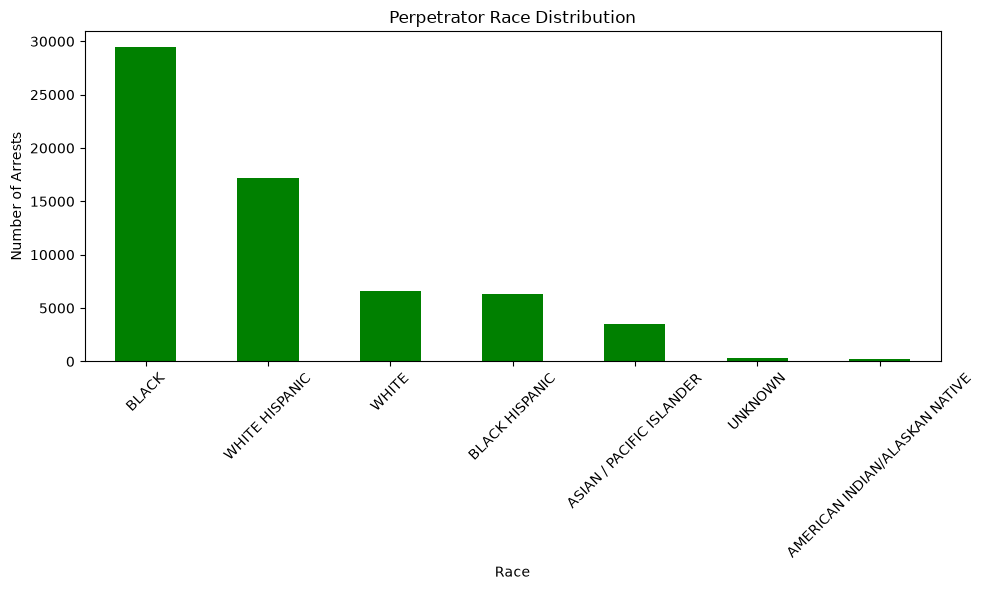

In [45]:
# Bar chart for the race_distribution 
race_distribution = nypd_df['ETHNICITY'].value_counts()

# Plotting the bar chart
plt.figure(figsize=(10, 6))
race_distribution.plot(kind='bar', color='green')
plt.title('Perpetrator Race Distribution')
plt.xlabel('Race')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
#What is the gender distribution of the arrested individuals??
gender_distribution_df = nypd_df['GENDER'].value_counts()


gender_distribution_df

GENDER
M    52432
F    11189
Name: count, dtype: int64

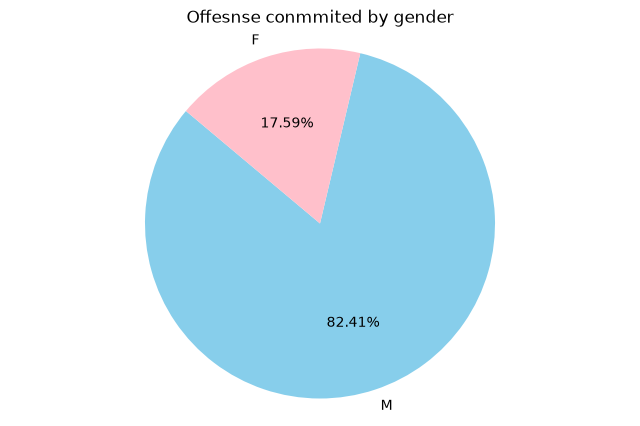

In [47]:
#Pie chart to illustrate gender distribution of arrested individuals 

plt.figure(figsize=(8, 5))
plt.pie(gender_distribution_df, labels=gender_distribution_df.index, autopct='%1.2f%%', startangle=140, colors=['skyblue', 'pink'])
plt.title('Offesnse conmmited by gender')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
#Most common offenses by description 
common_offense = nypd_df['OFFENSE TYPE'].value_counts().idxmax()
#print(f'The most common offense is: {common_offense}')



AttributeError: 'str' object has no attribute 'head'

In [ ]:
# Ensure ARREST_DATE is in datetime format
NYPD_Arrest_Data_df['ARREST_DATE'] = pd.to_datetime(NYPD_Arrest_Data_df['ARREST_DATE'])

# Extract month and year
NYPD_Arrest_Data_df['ARREST_MONTH'] = NYPD_Arrest_Data_df['ARREST_DATE'].dt.to_period('M')

# Count arrests per month
arrests_per_month = NYPD_Arrest_Data_df['ARREST_MONTH'].value_counts().sort_index()
#print(arrests_per_month)


arrests_per_month.head()

ARREST_MONTH
2024-01    21462
2024-02    20719
2024-03    21440
Freq: M, Name: count, dtype: int64

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Drop rows with missing values (if appropriate)
df_clean = df.dropna(subset=['OFNS_DESC', 'LAW_CODE', 'ARREST_BORO', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE'])

# Convert columns to appropriate data types if needed
# For example, converting dates to datetime format
df_clean['ARREST_DATE'] = pd.to_datetime(df_clean['ARREST_DATE'], errors='coerce')

print(df_clean.info())

ARREST_KEY                    0
ARREST_DATE                   0
PD_CD                         2
PD_DESC                       0
KY_CD                         9
OFNS_DESC                     0
LAW_CODE                      0
LAW_CAT_CD                  402
ARREST_BORO                   0
JURISDICTION_CODE             0
ARREST_PRECINCT               0
AGE_GROUP                     0
PERP_SEX                      0
PERP_RACE                     0
X_COORD_CD                    0
Y_COORD_CD                    0
Latitude                      0
Longitude                     0
New Georeferenced Column      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63621 entries, 0 to 63620
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ARREST_KEY                63621 non-null  int64         
 1   ARREST_DATE               63621 non-null  datetime64[ns]
 2   PD_CD            

In [ ]:
# Define ordered categories for age groups if needed
age_order = ['<18', '18-24', '25-44', '45-64', '65+']
df_clean['AGE_GROUP'] = pd.Categorical(df_clean['AGE_GROUP'], categories=age_order, ordered=True)

# Confirm the changes
print(df_clean['AGE_GROUP'].unique())

['<18', '25-44', '65+', '45-64', '18-24']
Categories (5, object): ['<18' < '18-24' < '25-44' < '45-64' < '65+']


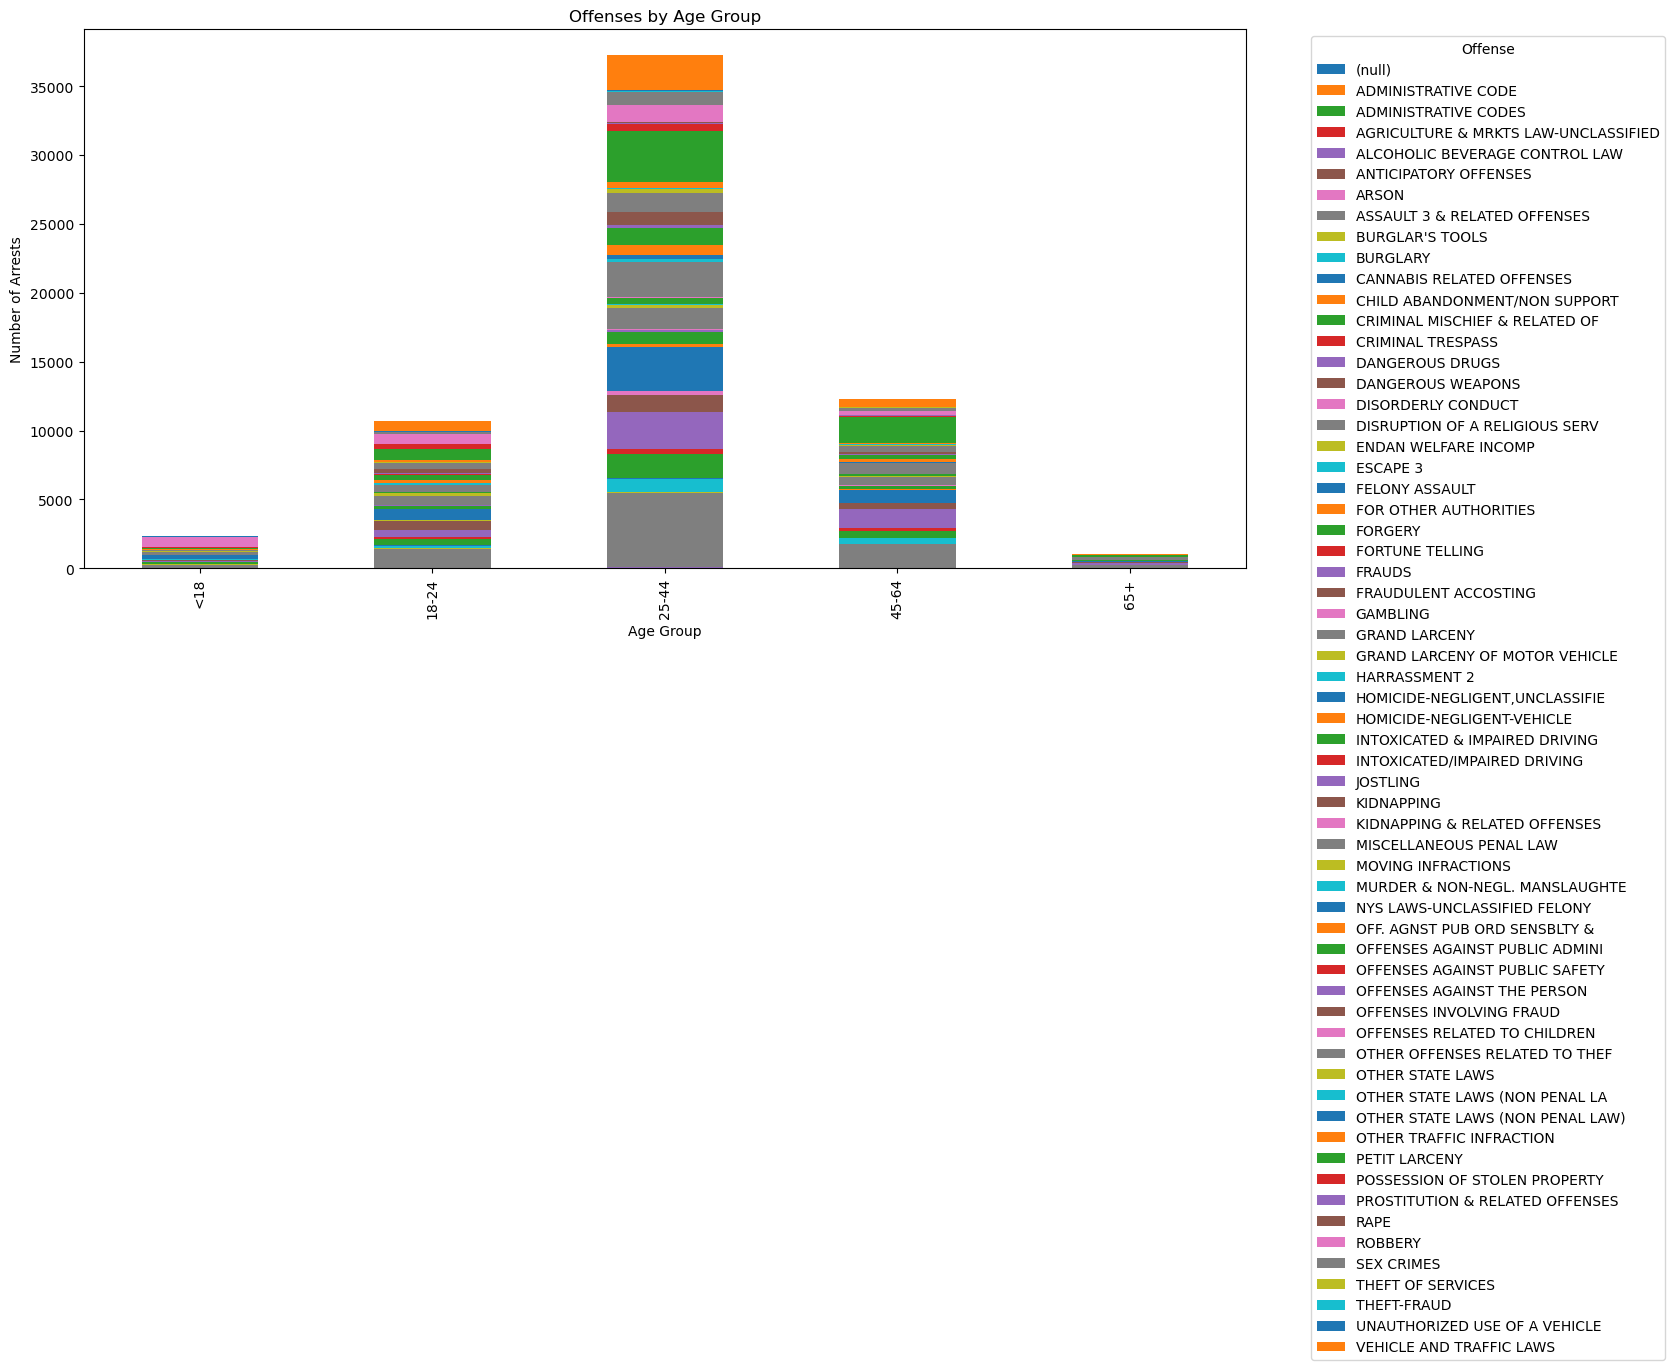

In [ ]:
# Count of offenses by age group
age_offense_counts = df_clean.groupby(['AGE_GROUP', 'OFNS_DESC']).size().unstack().fillna(0)

# Bar plot for offenses by age group
age_offense_counts.plot(kind='bar', stacked=True, figsize=(15, 7))
plt.title('Offenses by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Arrests')
plt.legend(title='Offense', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

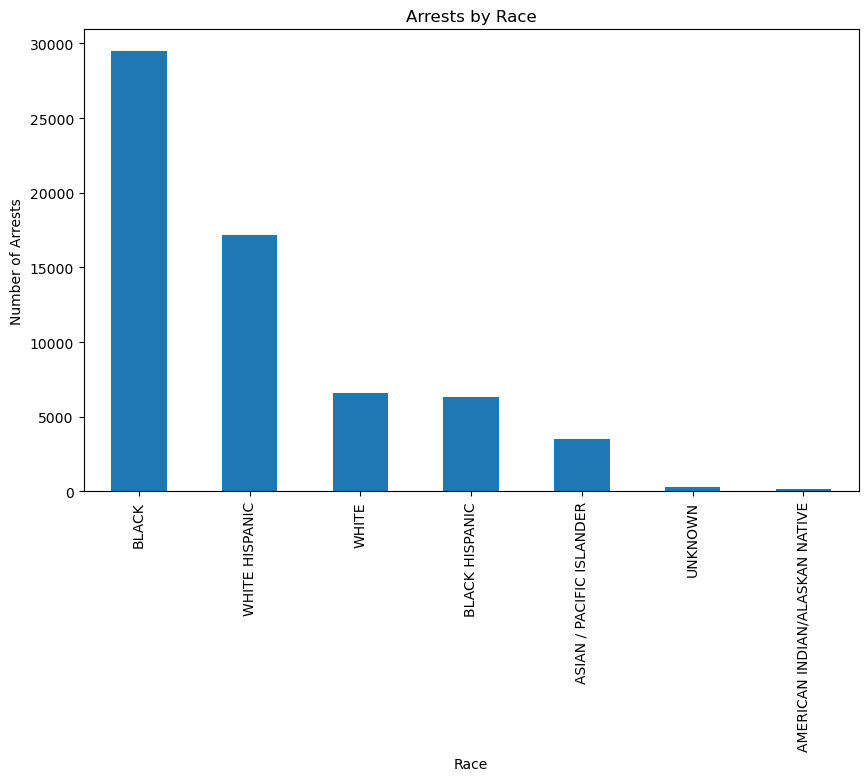

In [ ]:
# Count of arrests by race
race_arrest_counts = df_clean['PERP_RACE'].value_counts()

# Bar plot for arrests by race
race_arrest_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Arrests by Race')
plt.xlabel('Race')
plt.ylabel('Number of Arrests')
plt.show()

In [ ]:
# Convert the Series to a DataFrame
gender_distribution_df = gender_distribution.reset_index()

# Rename the columns for clarity
gender_distribution_df.columns = ['Gender', 'Count']

# Display the DataFrame
gender_distribution_df

,Gender,Count
0,M,52432
1,F,11189


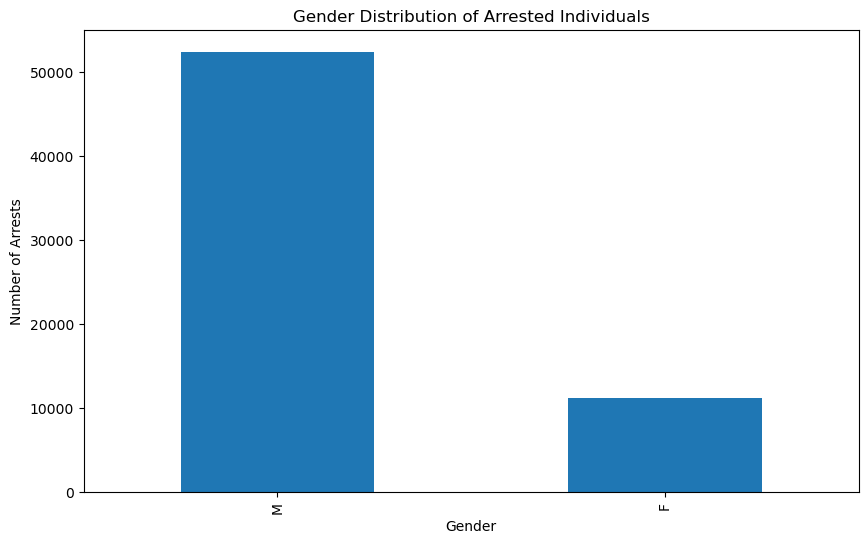

In [ ]:
# Bar plot for gender distribution
gender_distribution_df.plot(kind='bar', x='Gender', y='Count', legend=False, figsize=(10, 6))
plt.title('Gender Distribution of Arrested Individuals')
plt.xlabel('Gender')
plt.ylabel('Number of Arrests')
plt.show()

  LAW_CAT_CD  Count
0          M  52074
1          F  11145


C:\Users\A1990\AppData\Local\Temp\ipykernel_12816\2351775681.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['AGE_GROUP'] = pd.Categorical(df_clean['AGE_GROUP'], categories=age_order, ordered=True)


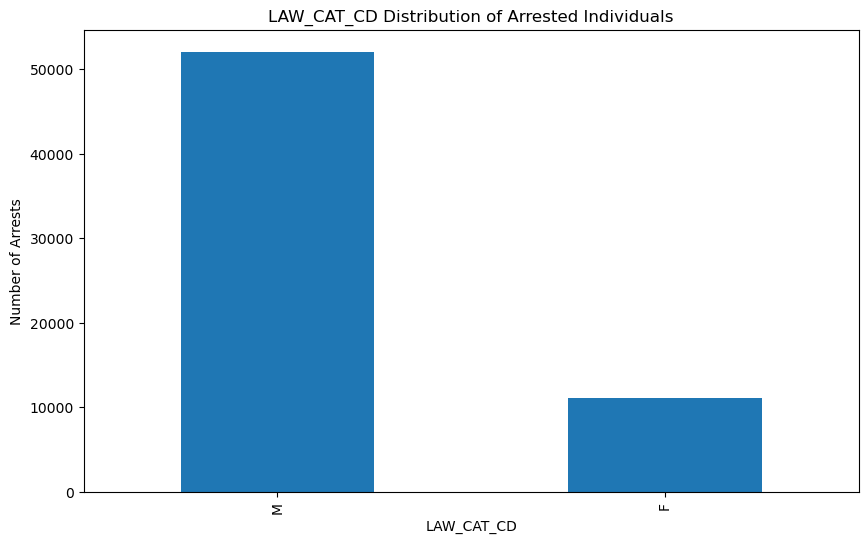

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Creating a csv file path
NYPD_Arrest_Data = r'C:\Users\A1990\Data_Project_1\NYPD_Arrest_Data__Year_to_Date__20240702.csv'

# Load the CSV file into a DataFrame
df = pd.read_csv(NYPD_Arrest_Data)

# Clean the data by dropping rows with missing values
df_clean = df.dropna(subset=['OFNS_DESC', 'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE'])

# Define ordered categories for age groups if needed
age_order = ['<18', '18-24', '25-44', '45-64', '65+']
df_clean['AGE_GROUP'] = pd.Categorical(df_clean['AGE_GROUP'], categories=age_order, ordered=True)

# Calculate the gender distribution
LAW_CAT_CD_distribution = df_clean['PERP_SEX'].value_counts()

# Convert the Series to a DataFrame
LAW_CAT_CD_distribution_df = LAW_CAT_CD_distribution.reset_index()

# Rename the columns for clarity
LAW_CAT_CD_distribution_df.columns = ['LAW_CAT_CD', 'Count']

# Display the DataFrame
print(LAW_CAT_CD_distribution_df)

# Bar plot for gender distribution
LAW_CAT_CD_distribution_df.plot(kind='bar', x='LAW_CAT_CD', y='Count', legend=False, figsize=(10, 6))
plt.title('LAW_CAT_CD Distribution of Arrested Individuals')
plt.xlabel('LAW_CAT_CD')
plt.ylabel('Number of Arrests')
plt.show()